[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bruskez/market-basket-analysis-imdb/blob/main/market_basket_analysis.ipynb)

In [ ]:
# Repository configuration (update after publishing the project on GitHub)
GITHUB_USER = "bruskez"
GITHUB_REPO = "market-basket-analysis-imdb"
NOTEBOOK_PATH = "market_basket_analysis.ipynb"


# Project 2 - Market-Basket Analysis on the IMDb Top 1000 Dataset

**Goal**: find groups of actors who recur frequently together in the same movies, treating each movie as a *basket* and the actors in the `Star1`-`Star4` fields as *items*.

**Techniques implemented (from scratch, no frequent-itemset-mining library):**
- **Apriori** (Rajaraman, Leskovec & Ullman, *Mining of Massive Datasets*, ch. 6.2-6.3)
- **PCY** (Park-Chen-Yu, ch. 6.3.1) - hash-based optimization of Apriori
- **Association rules** (confidence, interest)

The notebook is organized as: (1) data loading and exploration, (2) Apriori implementation and run, (3) PCY implementation and comparison, (4) association rules, (5) conclusions.

In [2]:
import itertools
import hashlib
import time
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
%matplotlib inline

### Dataset retrieval (Google Colab compatible)

The cell below works both locally (if `imdb_top_1000.csv` is already in the working directory) and on Google Colab: it first tries to download the file from the project's GitHub repository; if that fails (e.g., private or not-yet-published repository), it opens a manual upload widget.

In [ ]:
import os
import zipfile

os.environ['KAGGLE_USERNAME'] = "bruskez"
os.environ['KAGGLE_KEY'] = "KGAT_c5508c04d6abb3f2e6ac2aa84d7f2b73"

!pip install kaggle -q
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

with zipfile.ZipFile("imdb-dataset-of-top-1000-movies-and-tv-shows.zip", "r") as z:
    z.extractall(".")

CSV_PATH = "imdb_top_1000.csv"
print("Dataset ready:", CSV_PATH)

Dataset ready: imdb_top_1000.csv


## 1. Data loading and basket construction

Each row of the CSV is a movie. The `Star1`, `Star2`, `Star3`, `Star4` columns contain the 4 lead actors. We build one *basket* per movie as a `set` of actors, to avoid duplicates and any dependency on column order.

In [4]:
df = pd.read_csv(CSV_PATH)
print("Rows in dataset:", len(df))
df[["Series_Title", "Star1", "Star2", "Star3", "Star4"]].head()

Rows in dataset: 1000


,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


In [5]:
def load_baskets(dataframe):
    star_cols = ["Star1", "Star2", "Star3", "Star4"]
    baskets, titles = [], []
    for _, row in dataframe.iterrows():
        items = {row[c] for c in star_cols if pd.notna(row[c])}
        if items:
            baskets.append(items)
            titles.append(row["Series_Title"])
    return baskets, titles

baskets, titles = load_baskets(df)
N = len(baskets)
print(f"Number of baskets (movies): {N}")
print(f"Number of unique actors:    {len({a for b in baskets for a in b})}")
print(f"Average basket size:        {sum(len(b) for b in baskets)/N:.2f}")

Number of baskets (movies): 1000
Number of unique actors:    2709
Average basket size:        4.00


**Observation**: every movie has exactly 4 actors listed (no missing values in Star1-4). The distribution of actor frequency is heavily skewed: most actors appear in only one movie, while a few appear in many (e.g., Robert De Niro in 17 of 1000 movies). This means that, to get non-trivial results, the minimum support threshold must be low (a handful of movies, not a high percentage).

## 2. Apriori algorithm

Apriori exploits the **monotonicity (downward-closure)** property: if an itemset is not frequent, none of its supersets can be frequent either. The algorithm proceeds in increasing levels of size `k`:

1. **k=1**: count the support of every single item, keep only those `>= min_support` (set `L1`).
2. **k>1**: generate candidates of size `k` by combining frequent itemsets of size `k-1` (*join step*), discard candidates with a non-frequent `k-1`-subset (*prune step*), then count the real support by scanning the baskets and keep only those `>= min_support`.
3. Repeat until no more frequent itemsets are found.

In [6]:
def apriori_singletons(baskets, min_support):
    counts = defaultdict(int)
    for basket in baskets:
        for item in basket:
            counts[frozenset([item])] += 1
    return {iset: c for iset, c in counts.items() if c >= min_support}


def apriori_generate_candidates(prev_frequent, k):
    """Join step + prune step (every (k-1)-subset must be frequent)."""
    prev_sets = list(prev_frequent.keys())
    candidates = set()
    n = len(prev_sets)
    for i in range(n):
        for j in range(i + 1, n):
            union = prev_sets[i] | prev_sets[j]
            if len(union) != k:
                continue
            if all(frozenset(sub) in prev_frequent for sub in itertools.combinations(union, k - 1)):
                candidates.add(union)
    return candidates


def apriori_count_candidates(baskets, candidates, k):
    """Exact counting: for each basket, generate its k-subsets (at most a
    handful, since baskets have only 4 items) and check membership in the
    candidate set with an O(1) lookup in a hash set, instead of comparing
    every candidate against every basket (which would be needlessly slow)."""
    counts = defaultdict(int)
    for basket in baskets:
        if len(basket) < k:
            continue
        for combo in itertools.combinations(sorted(basket), k):
            c = frozenset(combo)
            if c in candidates:
                counts[c] += 1
    return counts


def run_apriori(baskets, min_support, max_k=10, verbose=False):
    levels, stats = {}, {}

    t0 = time.perf_counter()
    L1 = apriori_singletons(baskets, min_support)
    t1 = time.perf_counter()
    levels[1] = L1
    stats[1] = {"n_candidates": len(L1), "n_frequent": len(L1), "time_sec": t1 - t0}

    k, prev = 2, L1
    while prev and k <= max_k:
        t0 = time.perf_counter()
        candidates = apriori_generate_candidates(prev, k)
        if not candidates:
            break
        counts = apriori_count_candidates(baskets, candidates, k)
        Lk = {iset: c for iset, c in counts.items() if c >= min_support}
        t1 = time.perf_counter()
        stats[k] = {"n_candidates": len(candidates), "n_frequent": len(Lk), "time_sec": t1 - t0}
        if verbose:
            print(f"k={k}: {len(candidates)} candidates -> {len(Lk)} frequent ({t1 - t0:.4f}s)")
        if not Lk:
            break
        levels[k] = Lk
        prev, k = Lk, k + 1

    return levels, stats

### Run with `min_support = 3`

A threshold of 3 movies means: "this group of actors must appear together in at least 3 of the 1000 top-1000 movies".

In [7]:
MIN_SUPPORT = 3
levels, apriori_stats = run_apriori(baskets, MIN_SUPPORT, verbose=True)

for k in sorted(levels):
    print(f"\nTop frequent itemsets of size {k}:")
    top = sorted(levels[k].items(), key=lambda x: -x[1])[:5]
    for iset, c in top:
        print(f"  {{{', '.join(sorted(iset))}}}  support={c}")

k=2: 36585 candidates -> 25 frequent (0.1599s)
k=3: 4 candidates -> 3 frequent (0.0127s)

Top frequent itemsets of size 1:
  {Robert De Niro}  support=17
  {Tom Hanks}  support=14
  {Al Pacino}  support=13
  {Brad Pitt}  support=12
  {Clint Eastwood}  support=12

Top frequent itemsets of size 2:
  {Daniel Radcliffe, Rupert Grint}  support=6
  {Daniel Radcliffe, Emma Watson}  support=5
  {Emma Watson, Rupert Grint}  support=5
  {Joe Pesci, Robert De Niro}  support=4
  {Tim Allen, Tom Hanks}  support=4

Top frequent itemsets of size 3:
  {Daniel Radcliffe, Emma Watson, Rupert Grint}  support=5
  {Elijah Wood, Ian McKellen, Orlando Bloom}  support=3
  {Carrie Fisher, Harrison Ford, Mark Hamill}  support=3


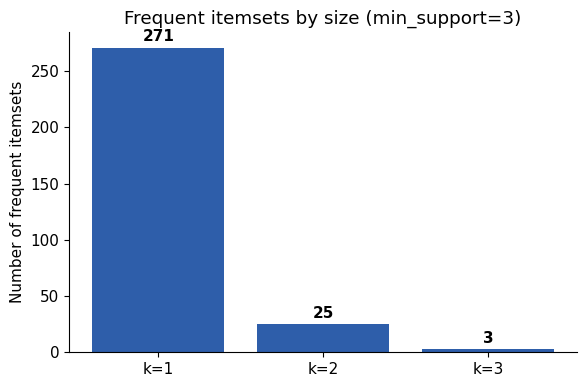

In [8]:
sizes = sorted(levels.keys())
counts = [len(levels[k]) for k in sizes]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f"k={k}" for k in sizes], counts, color="#2E5EAA")
for i, c in enumerate(counts):
    ax.text(i, c + max(counts) * 0.02, str(c), ha="center", fontweight="bold")
ax.set_ylabel("Number of frequent itemsets")
ax.set_title(f"Frequent itemsets by size (min_support={MIN_SUPPORT})")
fig.tight_layout()
plt.show()

### Combinatorial explosion: support-threshold sensitivity analysis

Lowering the support threshold causes the number of candidate itemsets (and thus computation time) to grow very quickly: with `min_support=2`, we reach 641 frequent actors, generating over 200,000 candidate pairs from the *join step* alone. This is exactly the scalability problem that algorithms like PCY try to mitigate.

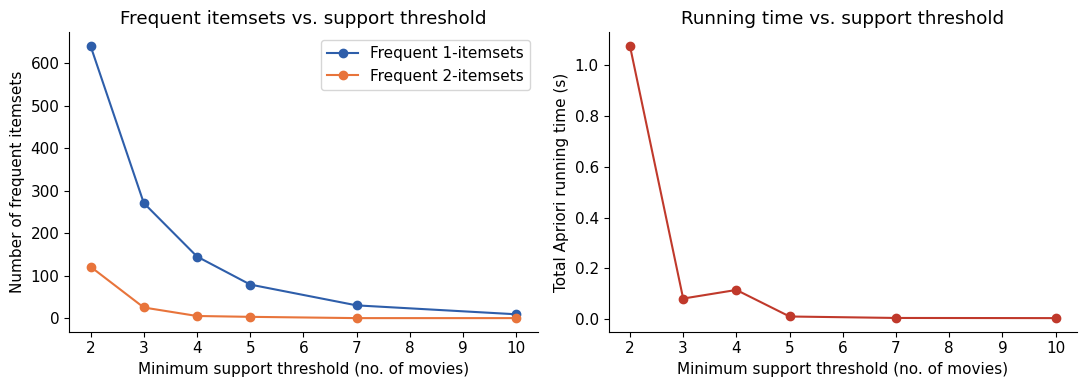

In [9]:
sweep_supports = [2, 3, 4, 5, 7, 10]
sweep_n_items, sweep_n_pairs, sweep_time = [], [], []
for ms in sweep_supports:
    lv, st = run_apriori(baskets, ms)
    sweep_n_items.append(len(lv.get(1, {})))
    sweep_n_pairs.append(len(lv.get(2, {})))
    sweep_time.append(sum(s["time_sec"] for s in st.values()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sweep_supports, sweep_n_items, "o-", color="#2E5EAA", label="Frequent 1-itemsets")
ax1.plot(sweep_supports, sweep_n_pairs, "o-", color="#E8743B", label="Frequent 2-itemsets")
ax1.set_xlabel("Minimum support threshold (no. of movies)")
ax1.set_ylabel("Number of frequent itemsets")
ax1.set_title("Frequent itemsets vs. support threshold")
ax1.legend()

ax2.plot(sweep_supports, sweep_time, "o-", color="#C0392B")
ax2.set_xlabel("Minimum support threshold (no. of movies)")
ax2.set_ylabel("Total Apriori running time (s)")
ax2.set_title("Running time vs. support threshold")
fig.tight_layout()
plt.show()

## 3. PCY algorithm (Park-Chen-Yu)

PCY optimizes Apriori's most expensive step (finding frequent pairs) by reducing the size of the **candidate set** that must be tracked. It works in two passes:

- **Pass 1**: besides counting the support of single items (as in Apriori), every pair of items in a basket is hashed into one of `num_buckets` buckets, incrementing a counter for that bucket. At the end, a bucket is "frequent" if the total of pairs that hashed into it is `>= min_support`.
- **Pass 2**: a pair becomes a *candidate* only if **both items are frequent singletons** *and* the pair hashes to a **frequent bucket**. Only these pairs are exactly counted.

**Key property (no false negatives)**: if a pair is genuinely frequent, its bucket receives at least `min_support` increments (from the pair itself), so the bucket will always be marked frequent. PCY never loses a truly frequent pair: it only filters out superfluous candidates (false positives).

In [10]:
def _hash_pair(pair, num_buckets):
    """Deterministic hash (stable across runs, unlike Python's hash())."""
    s = ",".join(sorted(pair))
    return int(hashlib.md5(s.encode()).hexdigest(), 16) % num_buckets


def pcy_pass1(baskets, min_support, num_buckets):
    item_counts = defaultdict(int)
    bucket_counts = defaultdict(int)
    for basket in baskets:
        items = list(basket)
        for item in items:
            item_counts[item] += 1
        for pair in itertools.combinations(sorted(items), 2):
            bucket_counts[_hash_pair(pair, num_buckets)] += 1
    frequent_items = {i for i, c in item_counts.items() if c >= min_support}
    frequent_buckets = {b for b, c in bucket_counts.items() if c >= min_support}
    return frequent_items, frequent_buckets


def pcy_pass2(baskets, frequent_items, frequent_buckets, min_support, num_buckets):
    candidate_counts = defaultdict(int)
    for basket in baskets:
        items = sorted(i for i in basket if i in frequent_items)
        for pair in itertools.combinations(items, 2):
            if _hash_pair(pair, num_buckets) in frequent_buckets:
                candidate_counts[frozenset(pair)] += 1
    return {p: c for p, c in candidate_counts.items() if c >= min_support}


def run_pcy_pairs(baskets, min_support, num_buckets=2000):
    t0 = time.perf_counter()
    frequent_items, frequent_buckets = pcy_pass1(baskets, min_support, num_buckets)
    t1 = time.perf_counter()
    frequent_pairs = pcy_pass2(baskets, frequent_items, frequent_buckets, min_support, num_buckets)
    t2 = time.perf_counter()

    # size of the candidate set PCY actually needs to track in pass 2
    n_pcy_candidates = sum(
        1 for a, b in itertools.combinations(sorted(frequent_items), 2)
        if _hash_pair((a, b), num_buckets) in frequent_buckets
    )
    stats = {
        "n_frequent_items": len(frequent_items),
        "n_buckets": num_buckets,
        "n_frequent_buckets": len(frequent_buckets),
        "n_pcy_candidates": n_pcy_candidates,
        "n_frequent_pairs": len(frequent_pairs),
        "pass1_time_sec": t1 - t0,
        "pass2_time_sec": t2 - t1,
        "total_time_sec": t2 - t0,
    }
    return frequent_pairs, stats

In [11]:
pcy_pairs, pcy_stats = run_pcy_pairs(baskets, MIN_SUPPORT, num_buckets=5000)
print(pcy_stats)

# Correctness check: Apriori and PCY must find EXACTLY the same frequent pairs
assert set(levels[2].keys()) == set(pcy_pairs.keys())
print("\nOK: Apriori and PCY find the same set of frequent pairs.")

{'n_frequent_items': 271, 'n_buckets': 5000, 'n_frequent_buckets': 626, 'n_pcy_candidates': 4854, 'n_frequent_pairs': 25, 'pass1_time_sec': 0.012577952000015102, 'pass2_time_sec': 0.002449544999990394, 'total_time_sec': 0.015027497000005496}

OK: Apriori and PCY find the same set of frequent pairs.


### Apriori vs PCY comparison: candidate-set size

PCY's real advantage is not (on a small dataset like this) raw speed, but the **reduction in the size of the counting table** needed in pass 2 - crucial when the number of items is large and the table of all candidate pairs would not fit in memory.

Apriori candidates (all pairs of L1): 36585
PCY candidates (after hash filter):   4854
Reduction: 86.7%


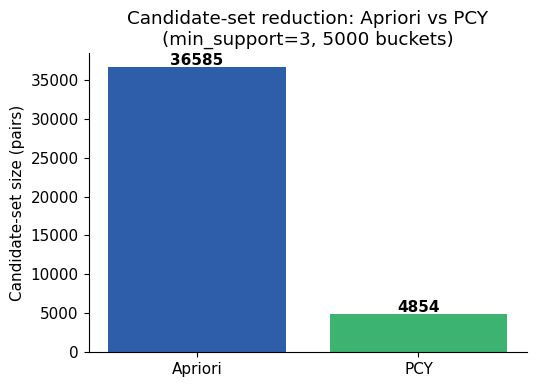

In [12]:
apriori_k2_candidates = apriori_stats[2]["n_candidates"]
pcy_k2_candidates = pcy_stats["n_pcy_candidates"]
reduction_pct = 100 * (1 - pcy_k2_candidates / apriori_k2_candidates)

print(f"Apriori candidates (all pairs of L1): {apriori_k2_candidates}")
print(f"PCY candidates (after hash filter):   {pcy_k2_candidates}")
print(f"Reduction: {reduction_pct:.1f}%")

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(["Apriori", "PCY"], [apriori_k2_candidates, pcy_k2_candidates], color=["#2E5EAA", "#3CB371"])
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + apriori_k2_candidates*0.01, str(int(h)), ha="center", fontweight="bold")
ax.set_ylabel("Candidate-set size (pairs)")
ax.set_title(f"Candidate-set reduction: Apriori vs PCY\n(min_support={MIN_SUPPORT}, {pcy_stats['n_buckets']} buckets)")
fig.tight_layout()
plt.show()

### Effect of the number of buckets

The number of buckets is a key parameter: too few buckets cause many hash collisions, defeating the filter (every bucket becomes "frequent" and PCY behaves like Apriori). Too many buckets instead reduce collisions and bring the candidate set closer to the true number of frequent pairs.

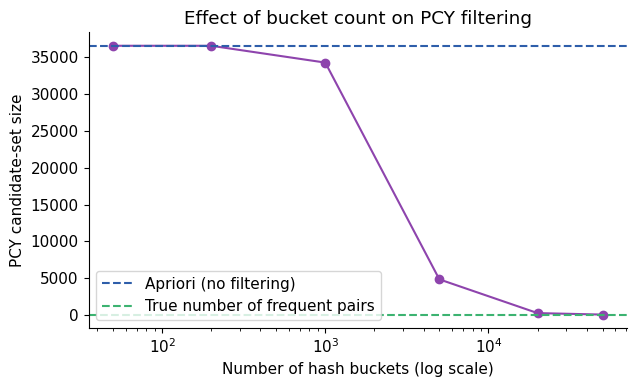

In [13]:
bucket_sweep = [50, 200, 1000, 5000, 20000, 50000]
bucket_candidates = []
for nb in bucket_sweep:
    _, st = run_pcy_pairs(baskets, MIN_SUPPORT, num_buckets=nb)
    bucket_candidates.append(st["n_pcy_candidates"])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(bucket_sweep, bucket_candidates, "o-", color="#8E44AD")
ax.axhline(apriori_k2_candidates, color="#2E5EAA", linestyle="--", label="Apriori (no filtering)")
ax.axhline(len(levels[2]), color="#3CB371", linestyle="--", label="True number of frequent pairs")
ax.set_xscale("log")
ax.set_xlabel("Number of hash buckets (log scale)")
ax.set_ylabel("PCY candidate-set size")
ax.set_title("Effect of bucket count on PCY filtering")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Association rules

Following the course definition: an association rule has the form **I &#8594; j**, where **I is a set of items** and **j is a single item** (not a set). For every frequent itemset of size >= 2, for every item `j` it contains, we generate the rule `(itemset - {j}) -> j` and compute:

- **confidence** = support(I &#8746; {j}) / support(I) - the fraction of baskets containing all of I that also contain j.
- **interest** = confidence - support({j})/N - the difference between the observed confidence and the "baseline" frequency of j. A high (positive) interest means I encourages the presence of j; a strongly negative interest means I discourages it (see the coke/pepsi example in the course notes).

In [14]:
def generate_association_rules(levels, n_baskets, min_confidence=0.5):
    """Rules I -> j (single-item j), as defined in the course."""
    support = {}
    for itemsets in levels.values():
        support.update(itemsets)
    singleton_support = {next(iter(k)): v for k, v in levels.get(1, {}).items()}

    rules = []
    for k, itemsets in levels.items():
        if k < 2:
            continue
        for itemset, itemset_support in itemsets.items():
            for j in itemset:
                antecedent = itemset - frozenset([j])
                ant_support = support.get(antecedent)
                if not ant_support:
                    continue
                confidence = itemset_support / ant_support
                if confidence < min_confidence:
                    continue
                j_prob = singleton_support.get(j, 0) / n_baskets
                interest = confidence - j_prob
                rules.append({
                    "antecedent": antecedent, "consequent": j,
                    "support": itemset_support, "confidence": confidence, "interest": interest,
                })
    rules.sort(key=lambda r: abs(r["interest"]), reverse=True)
    return rules

rules = generate_association_rules(levels, N, min_confidence=0.5)
print(f"Rules generated (confidence >= 0.5): {len(rules)}\n")
for r in rules[:10]:
    ant = ", ".join(sorted(r["antecedent"]))
    print(f"  {{{ant}}} -> {r['consequent']}   support={r['support']}  conf={r['confidence']:.2f}  interest={r['interest']:+.3f}")

Rules generated (confidence >= 0.5): 39

  {Ian McKellen, Orlando Bloom} -> Elijah Wood   support=3  conf=1.00  interest=+0.997
  {Carrie Fisher, Harrison Ford} -> Mark Hamill   support=3  conf=1.00  interest=+0.997
  {Elijah Wood} -> Orlando Bloom   support=3  conf=1.00  interest=+0.996
  {Mark Hamill} -> Carrie Fisher   support=3  conf=1.00  interest=+0.996
  {Elijah Wood, Ian McKellen} -> Orlando Bloom   support=3  conf=1.00  interest=+0.996
  {Harrison Ford, Mark Hamill} -> Carrie Fisher   support=3  conf=1.00  interest=+0.996
  {Daniel Radcliffe} -> Rupert Grint   support=6  conf=1.00  interest=+0.994
  {Rupert Grint} -> Daniel Radcliffe   support=6  conf=1.00  interest=+0.994
  {John Turturro} -> Ethan Coen   support=3  conf=1.00  interest=+0.994
  {Daniel Radcliffe, Emma Watson} -> Rupert Grint   support=5  conf=1.00  interest=+0.994


## 5. Insight: the most recurring actor pairs

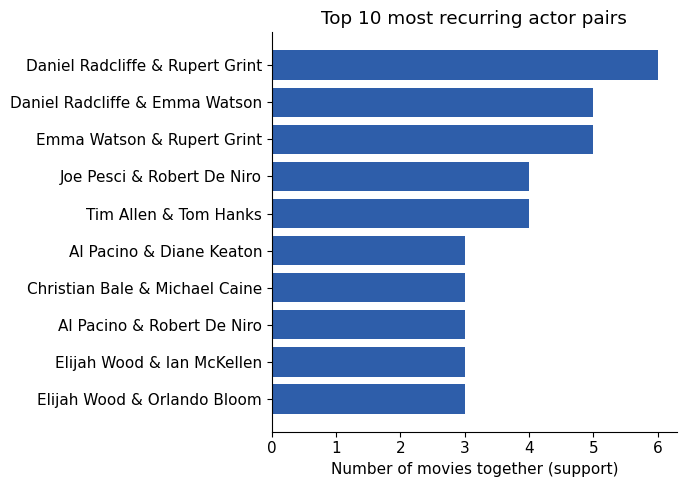

In [15]:
top_pairs = sorted(levels[2].items(), key=lambda x: -x[1])[:10]
labels = [" & ".join(sorted(p)) for p, _ in top_pairs]
values = [c for _, c in top_pairs]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(labels[::-1], values[::-1], color="#2E5EAA")
ax.set_xlabel("Number of movies together (support)")
ax.set_title("Top 10 most recurring actor pairs")
fig.tight_layout()
plt.show()

## 6. Conclusions

- Out of 1000 movies and 2709 unique actors, with `min_support=3` we find **271 frequent actors**, **25 frequent pairs**, and **3 frequent triples** (k=4 yields no results: no group of 4 actors recurs in at least 3 of the top-1000 movies).
- The most frequent pairs/triples correspond, as expected, to recurring film-franchise casts (e.g., the Harry Potter trio, the Lord of the Rings cast, the Star Wars cast).
- **Apriori and PCY find exactly the same frequent pairs** (no false negatives), but PCY substantially reduces the size of the candidate set to track in pass 2 (by over 85% with a well-chosen bucket count) - a practical confirmation of the theoretical advantage, which would become even more pronounced on datasets with many more items.
- Lowering the support threshold causes the number of candidates to grow very quickly (combinatorial explosion), confirming why techniques like PCY matter when working with more permissive thresholds or much larger item catalogues.

**Limitations and possible extensions**: the IMDb Top 1000 dataset is relatively small and already "pre-filtered" (only high-quality/popular movies), so the most frequent actors tend to be tied to a few major productions. A larger movie dataset (not just the top 1000) would likely yield more frequent itemsets and an even larger PCY advantage. The work could also be extended with the SON algorithm for distributed execution (Spark/MapReduce), in line with the other topics covered in the course.